In [62]:
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt
import json
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
import os

MODEL_DIR = "../models/biobert_ner/checkpoint-3939"
PROCESSED_DIR = "../data/processed/"
OUTPUT_DIR = "../outputs/"
os.makedirs(OUTPUT_DIR, exist_ok = True)

In [63]:
LABEL2ID = {"O": 0, "B-ADR": 1, "I-ADR": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForTokenClassification.from_pretrained(MODEL_DIR)
model.eval()

print("Model loaded")
print("Labels:", ID2LABEL)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model loaded
Labels: {0: 'O', 1: 'B-ADR', 2: 'I-ADR'}


In [64]:
ner_pipeline = pipeline(
    "ner",
    model = model,
    tokenizer = tokenizer,
    aggregation_strategy = "simple", # merges B-ADR and I-ADR to form one entity,
    device=0 if torch.cuda.is_available() else -1
)

# Test it on one review before touching SHAP
test_review = "I took this medication for a week and experienced severe nausea and dry mouth"
result = ner_pipeline(test_review)

print("NER predictions:")
for r in result:
    print(f"  {r['word']:<20} {r['entity_group']:<10} score: {r['score']:.3f}")

NER predictions:
  nausea               ADR        score: 0.999
  dry mouth            ADR        score: 0.979


In [65]:
print()

In [66]:
print(result)

[{'entity_group': 'ADR', 'score': 0.99928397, 'word': 'nausea', 'start': 57, 'end': 63}, {'entity_group': 'ADR', 'score': 0.97853464, 'word': 'dry mouth', 'start': 68, 'end': 77}]


In [67]:
# SHAP needs a function that takes a list of strings and returns scores
# We wrap the NER pipeline to return ADR probability per token

def adr_score(texts):
    """
    For each text, returns the maximum ADR confidence score found.
    SHAP will measure how each token contributes to this score.
    """
    scores = []
    for text in texts:
        predictions = ner_pipeline(text)
        adr_preds = [p for p in predictions if p["entity_group"] in("ADR")]
        if adr_preds:
            scores.append(max(p['score'] for p in adr_preds))
        else:
            scores.append(0.0)
    return np.array(scores)

# Build explainer — masker handles token masking strategy
masker = shap.maskers.Text(tokenizer=r"\W+")
explainer =shap.Explainer(adr_score, masker)

print("SHAP explainer ready")

# Quick test
test_score = adr_score([test_review])
print(f"ADR score for test review: {test_score[0]:.3f}")
    

    

SHAP explainer ready
ADR score for test review: 0.999


In [68]:
print(test_score)

[0.99928397]


In [69]:
# Select a few diverse reviews to explain
# Pick ones where the model is confident — more interesting visualizations4
with open(os.path.join(PROCESSED_DIR, "bio_labeled_sample.json")) as f:
    records = json.load(f)
sample_reviews  =[]
# Find reviews with clear ADR predictions
for r in records[:500]: # first 500 samples
    text = r["review"]
    score = adr_score([text])[0]
    if score > 0.85: # high confidence review ADR prediction
        sample_reviews .append(text)
    if len(sample_reviews) ==20:
        break

print(f"Found {len(sample_reviews)} high confidence sample reviews")
for i, rev in enumerate(sample_reviews):
    print(f"\n{i+1}: {rev[:100]}...")


Found 20 high confidence sample reviews

1: "Worked fine for 2 days - burning and itching returned on day 3."...

2: "started sweating first few days after starting med, and had weird feelings this med was making it w...

3: "I was in the hospital for a week in January with colitis. Was prescribed Amitiza when I was release...

4: "I have been on Diamox since 2004 when I was first diagnosed with a pseudotumor cerebri. I was hospi...

5: "Well I have anxiety and have trouble getting to sleep or should I say don't get any sleep at all, I...

6: "When I first had pain 19 years ago, I was treated with Flexeril for six months. I thought I was get...

7: "I was on Cymbalta for 5 days. It helped my anxiety, but I couldn't handle the side effects: nausea,...

8: "It was a fine pill, only a little spotting. But during the off-week, my vagina would burn like craz...

9: "Save yourselves the pain of this horrible product. The discomfort I felt before I took this does no...

10: "I've been on a co

In [70]:
print("Computing SHAP values (this takes 3-5 minutes)...")

# Truncate reviews to 50 words max — SHAP is exponential in sequence length
sample_short = [" ".join(r.split()[:50]) for r in sample_reviews]
# print(sample_short)

shap_values = explainer(sample_short)

print("Done.")
print("SHAP values shape:", shap_values.shape)

Computing SHAP values (this takes 3-5 minutes)...


  0%|          | 0/156 [00:00<?, ?it/s]

PartitionExplainer explainer:   5%|████▊                                                                                            | 1/20 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  15%|█████████████▎                                                                           | 3/20 [01:18<08:49, 31.13s/it]

...

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|████████████████████████████████████████████████████████████████████████████████████████| 20/20 [16:26<00:00, 54.07s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 21it [17:24, 52.24s/it]                                                                                                      

Done.
SHAP values shape: (20, None)


In [71]:
# Visualization 1 — text plot for one review
# Red = pushes toward ADR, Blue = pushes away
print("Review 1 explanantion")
print(sample_short[0])
print()
shap.plots.text(explainer([sample_short[0]])[0])

Review 1 explanantion
"Worked fine for 2 days - burning and itching returned on day 3."



  0%|          | 0/156 [00:00<?, ?it/s]

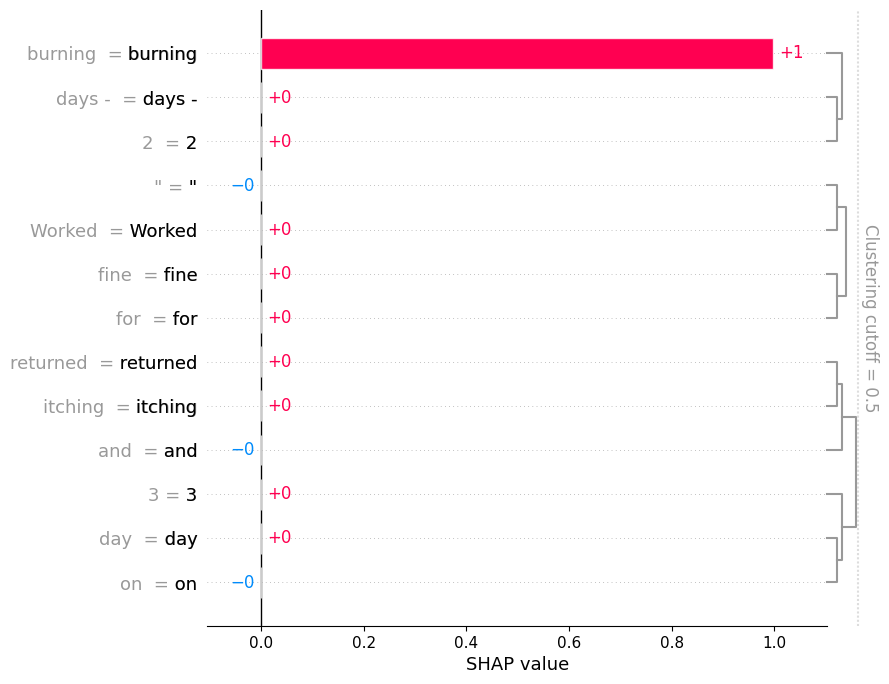

<Figure size 640x480 with 0 Axes>

In [72]:
# Visualization 2 — bar plot of top contributing tokens
shap.plots.bar(shap_values[0], max_display=15, show=True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_bar_review1.png"), dpi=150, bbox_inches='tight')

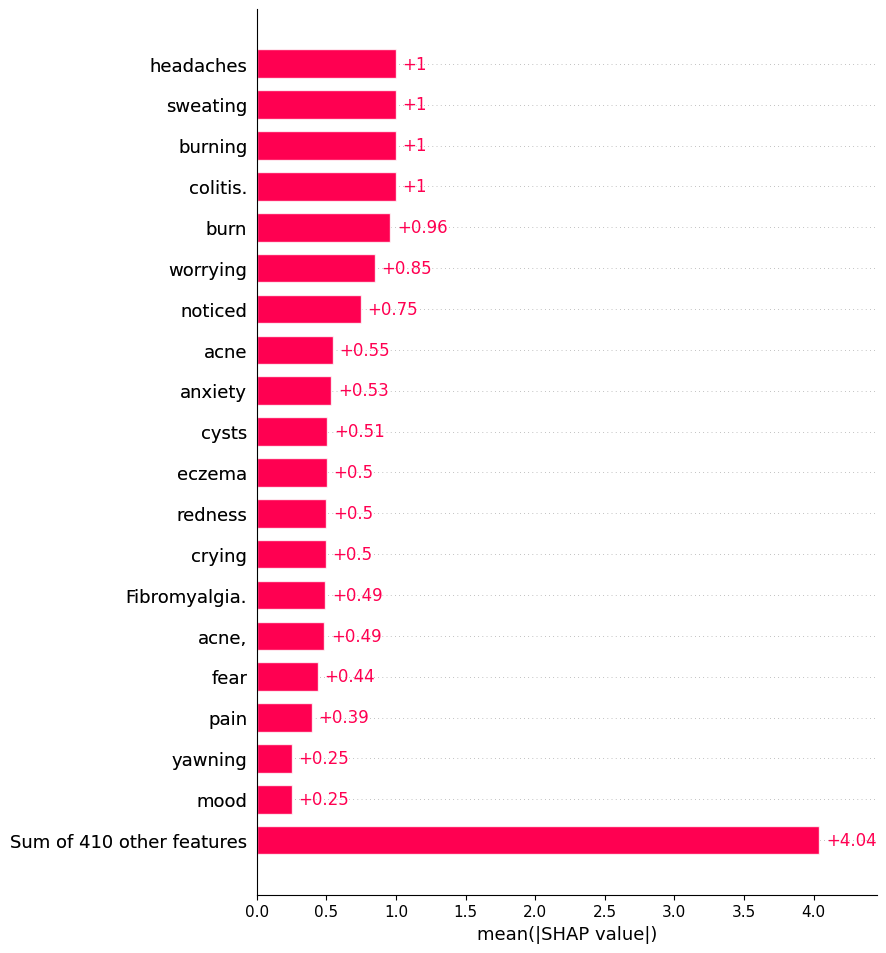

<Figure size 640x480 with 0 Axes>

In [73]:
shap.plots.bar(shap_values, max_display=20)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_bar.png"), dpi=150, bbox_inches='tight')

In [74]:
print(len(shap_values))

20


In [75]:
import pandas as pd

# Extract top tokens and their mean absolute SHAP value across all reviews
token_importance= {}
for i in range(len(shap_values)):
    for token, value in zip(shap_values[i].data, shap_values[i].values):
        token = token.lower().strip()
        if token not in token_importance:
            token_importance[token] = []
        token_importance[token].append(abs(value))
print(token_importance)

{'"': [0.00040519237518310547, 0.00034632906317710876, 0.00017433706670999527, 0.0009508999064564705, 0.00405864417552948, 0.008938755840063095, 0.0006037006775538126, 0.017040349543094635, 0.0006501693278551102, 0.0003380291163921356, 8.941628038883209e-05, 7.233023643493652e-05, 8.248910307884216e-05, 0.0005286075174808502, 0.02236112765967846, 0.00134962797164917, 0.0012907441705465317, 0.0, 0.0008776141330599785, 0.0008054645732045174], 'worked': [0.00033526867628097534, 2.0109206511109476e-05], 'fine': [0.00022368505597114563, 0.012865478172898293, 0.0011729132384061813], 'for': [0.00017892196774482727, 9.417533874511719e-06, 4.1025690734386444e-05, 0.0029329638928174973, 3.111238280932109e-05, 0.00022774282842874527, 0.012809796258807182, 0.001333234688410392, 0.0001990869641304016, 0.0009759832173585892, 0.0, 0.0057760365307331085, 0.01764974370598793, 0.0001639602705836296, 0.0, 0.00046507734805345535], '2': [4.409626126289368e-05, 7.31348991394043e-05, 0.0021795962626735372], 

In [76]:
# Average importance per token
token_df = pd.DataFrame([{
    "token": token,
    "mean_shap": np.mean(values),
    "count": len(values)
} for token, values in token_importance.items() if len(values)>=2]).sort_values("mean_shap", ascending = False)

print("Top 20 most important tokens across all reviews:")
print(token_df.head(20).to_string(index=False))

token_df.to_csv(os.path.join(OUTPUT_DIR, "shap_token_importance.csv"), index=False)

Top 20 most important tokens across all reviews:
   token  mean_shap  count
    acne   0.545856      3
  eczema   0.501750      2
    pain   0.394330      6
    mood   0.250628      2
    that   0.023117      5
   about   0.019024      2
      i'   0.016518      4
    well   0.013063      2
  almost   0.010235      3
flexeril   0.008745      3
    like   0.006343      2
      no   0.006198      7
  severe   0.006113      2
      ve   0.006098      3
    fine   0.004754      3
  during   0.004649      2
   days.   0.004568      2
      on   0.004567     11
   sleep   0.004437      2
       a   0.004313     20


In [77]:
token_df.head().to_string(index= False)

' token  mean_shap  count\n  acne   0.545856      3\neczema   0.501750      2\n  pain   0.394330      6\n  mood   0.250628      2\n  that   0.023117      5'

In [78]:
# Verify adr_score output shape — critical before running SHAP
test_batch = [
    "I experienced severe nausea and dry mouth",
    "This medication worked perfectly fine for me",
    "Headache and dizziness were unbearable"
]

scores =adr_score(test_batch)
print("Scores type: ", type(scores))
print("Scores shape: ", scores.shape)
print("Scores: ", scores)


Scores type:  <class 'numpy.ndarray'>
Scores shape:  (3,)
Scores:  [0.99944514 0.         0.99966884]


In [85]:
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords", quiet =True)

stop_words = set(stopwords.words("english"))

# Adding punctuations to the list of stop words
stop_words.update(['"', "'", '.', ',', '!', '?', '-', '(', ')', '``', "''"])

token_importance = {}
for i in range(len(shap_values)):
    for token, value in zip(shap_values[i].data, shap_values[i].values):
        token = token.lower().strip('.,!?"\'-()—')  # strip punctuation from token too
        # Filter 1: remove stop words
        if token in stop_words:
            continue
        # Filter 2: remove pure punctuation or single characters
        if len(token) <= 1:
            continue
        # Filter 3: remove digits
        if token.isdigit():
            continue

        if token not in token_importance:
            token_importance[token]= []
        token_importance[token].append(abs(value))

print(token_importance)   
token_df = pd.DataFrame([
    {"token": token, "mean_shap": np.mean(values), "count": len(values)}
    for token, values in token_importance.items()
]).sort_values("mean_shap", ascending=False)

print("Top 20 clinically relevant tokens:")
print(token_df.head(20).to_string(index=False))

token_df.to_csv(os.path.join(OUTPUT_DIR, "shap_token_importance.csv"), index=False)

{'worked ': [0.00033526867628097534, 2.0109206511109476e-05], 'fine ': [0.00022368505597114563, 0.012865478172898293, 0.0011729132384061813], 'for ': [0.00017892196774482727, 9.417533874511719e-06, 4.1025690734386444e-05, 0.0029329638928174973, 3.111238280932109e-05, 0.00022774282842874527, 0.012809796258807182, 0.001333234688410392, 0.0001990869641304016, 0.0009759832173585892, 0.0, 0.0057760365307331085, 0.01764974370598793, 0.0001639602705836296, 0.0, 0.00046507734805345535], '2 ': [4.409626126289368e-05, 7.31348991394043e-05, 0.0021795962626735372], 'days - ': [0.00023295357823371887], 'burning ': [0.9982810541987419], 'and ': [5.1043927669525146e-05, 0.00016339123249053955, 0.00014448165893554688, 8.186232298612595e-05, 0.0007496777921915055, 0.004490659882624944, 0.0024899731700619063, 0.0017311399181683858, 0.01057645616432031, 0.0024669449776411057, 0.0024967938661575317, 0.0012672978142897289, 0.00020742292205492655, 0.0016965917066523904, 0.0002852772864011618, 0.004131707549

In [86]:
print(token_df.head(10).to_string(index= False))

    token  mean_shap  count
headaches   0.999288      1
sweating    0.998507      1
 burning    0.998281      1
colitis.    0.997841      1
    burn    0.957777      1
worrying    0.849014      1
 noticed    0.748540      1
    acne    0.545856      3
 anxiety    0.533991      1
   cysts    0.506438      1


In [87]:
print(shap_values)

.values =
array([array([-4.05192375e-04,  3.35268676e-04,  2.23685056e-04,  1.78921968e-04,
               4.40962613e-05,  2.32953578e-04,  9.98281054e-01, -5.10439277e-05,
               7.85589218e-05,  2.32376158e-04, -8.92952085e-06,  3.44626606e-05,
               2.05449760e-04])                                                  ,
       array([-3.46329063e-04,  4.90870327e-04,  9.98507285e-01,  5.73461875e-04,
              -4.09781933e-05, -1.35563314e-05, -2.77208164e-05, -2.87862495e-05,
              -7.93505460e-05, -1.63391232e-04,  3.73385847e-05,  4.03858721e-05,
               8.68216157e-05,  4.78848815e-05,  6.22207299e-05,  4.49949875e-05,
               5.25508076e-05,  1.04010105e-05,  3.97758558e-05,  1.12225302e-04,
               3.85120511e-05,  2.15563923e-05, -3.20561230e-06, -2.27410346e-05,
               6.42202795e-05, -1.44481659e-04, -9.80496407e-06,  2.13570893e-05,
              -9.25734639e-07,  3.84263694e-06,  8.85836780e-05, -1.36122108e-05,
     

In [88]:
# Save the bar chart for README
shap.plots.bar(shap_values[0], max_display=15, show=False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_bar_review1.png"), 
            dpi=150, bbox_inches='tight')
plt.close()
print("Saved SHAP bar chart")

Saved SHAP bar chart
